In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize

In [16]:
##CURRENTLY POST INJECTION!! CHANGE IC IF DESIRED

In [17]:
def get_nominal_param():
    d1 = 1.35e-7 # min N-unit inverse
    # Parameters for phagocytes
    k1 = 4.9956e7 #N-unit Kg / min pg
    k2 = 12.94907 # ND
    h1 = 1693.9509 #pg/mL
    h2 = 0.07212   # pg/mL
    h3 = 147.68    # pg/mL
    d2 = 0.1439   # 1/min

    # Parameters for TGF beta
    k3 = 1.546*1e-9 # mL/pg N-unit min
    k4 = 0.5     # mL/pg min
    h4 = 500#*1e6/100     # pg / mL
    d3 = 0.031777 # 1/min

    # Parameters for TNF alpha
    h5 = 550e4   # N-unit
    h6 = 0.1589  # pg/mL
    k5 = 25.5194 # pg/mL min
    k6 = 3.5514e4 # pg/mL min
    h7 = 1.5495e3 # pg/mL
    d4 = 0.0293 #0.0307/1   #mL/pg min

    # Parameters for IL-10
    b1 = 1187.2 # pg/mL min
    k7 = 267480 #  pg/mL min
    h8 = 8.0506e7 # N-unit
    k8 = 43875 #  pg/mL min
    h9 = 0.38  # pg/mL
    d5 = 98.932 # 1/min
    h10 = 791.27 #pg/mL

    # Parameters for CRH
    b2 = 0.001 # pg/mL min
    k9 = 6.84e9 # pg/ml min
    k10 = 1.7558e9#/(1e12))*(100^2) #(mL/pg^2)
    k11 = 0.0667 # 1/min
    d6 = 0.032 #1/min

    # Parameters for ACTH
    k12 = 2.3688e4 #1/min
    k13 = 1.7778e5#/1e6)*100 #mL/pg
    k14 = 112 #pg/mL min
    h11 = 80 #pg/mL
    d7  = 0.016 # 1/min

    # Parameters for Cortisol
    k15 = 4.2541e-04#*1e6/100 #pg mL / mL min pg
    k16 = 12 # pg/mL
    d8  = 0.0266 #1/min

    # Parameters for the circadian rhythm
    alpha = 300 #min
    k     = 5 #ND
    beta = 950 #min
    L = 6 #ND
    eps = 0.01 #ND
    delta = 70#76.37 #min
    T = 1440 # min
    Nc = 1.9168


    param = [d1,            #0
    k1,k2,h1,h2,h3,d2,      #1-6
    k3,k4,h4,d3,            #7-10
    h5,h6,k5,k6,h7,d4,      #11-16
    b1,k7,h8,k8,h9,d5,h10,  #17-23
    b2,k9,k10,k11,d6,       #24-28
    k12,k13,k14,h11,d7,     #29-33
    k15,k16,d8,             #34 - 36
    alpha, k, beta, L, eps, delta, T, Nc #37-43
    ]
    param_log = np.log(param)

    #Initial Conditions
    endo_0 = 0
    phag_0 = 0
    TGFB_0 = 0.004/d3
    TNF_0  = 0
    IL10_0 = b1*h10/(d5*h10-b1)
    CRH_0  = 2
    ACTH_0 = 150
    cort_0 = 1.9

    # MJC - start this without the infection so we reach a steady state, then we can implement the infection
    IC = [ 0.0        ,  0.        ,  0.1595967 ,  0.        , 14.68266827,
        41.49891056, 39.97751646, 11.29827208]

    return param_log, IC

In [18]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [19]:
## ODE Model ##

def ITIS(y,t,param):
 endo,phag,TGFB,TNF,IL10,CRH,ACTH,cort = y

 (d1,
k1,k2,h1,h2,h3,d2,
k3,k4,h4,d3,
h5,h6,k5,k6,h7,d4,
b1,k7,h8,k8,h9,d5,h10,
b2,k9,k10,k11,d6,
k12,k13,k14,h11,d7,
k15,k16,d8,
alpha, k, beta, L, eps, delta, T, Nc) = np.exp(param)

#Circadian Rhythm
 tm = (t * 60 - delta) % T
 R_1 = tm**k / (tm**k + alpha**k)
 R_2 = ((T - tm)**L) / ((T - tm)**L + beta**L)
 R_func = Nc*(R_1*R_2 + eps)

#Other things
 phag1 = 1 + k2 * (TNF / (h1 + TNF))
 phag2 = (h2 / (h2+TGFB)) * (h3 / (h3 + IL10))

 tnf1 = (phag / (h5 + phag)) * (h6**4 / (h6**4 + TGFB**4))
 tnf2 = k5 + k6 * (TNF / (h7 + TNF))

 il10_1 = k7 * (phag**3 / (h8**3 + phag**3)) + k8 * (TGFB**6 / (h9**6 + TGFB**6))

 crh1 = R_func * k9 * (CRH / (1+k10*cort**2)) ##[RESOLVE]

#Differential equations
 dendo = -d1 * endo * phag
 dphag = k1 * (phag1 * phag2) * endo - d2 * phag
 dTGFB = k3 * phag + k4 * cort / (h4 + cort) - d3 * TGFB
 dTNF = tnf1 * tnf2 - d4 * (TNF**2)
 dIL10 = b1 + il10_1 - d5 * (h10 / (h10 + IL10)) * IL10
 dCRH = b2 * 60 + crh1 * 60 + k11 * TNF - d6 * CRH * 60
 dACTH = k12 * (CRH / (1 + k13 * cort)) * 60 + k14 * (TNF**2 / (h11**2 + TNF**2)) - d7 * ACTH * 60
 dcort = k15 * (ACTH **2 / (1 + k16 * TGFB)) * 60 - d8 * cort * 60

 dy = [dendo,dphag,dTGFB,dTNF,dIL10,dCRH,dACTH,dcort]
 return dy

In [20]:
def OLS_res(param_in,y_data,t_data,param_ids,output_ids,param_fix,IC):
    # First, we may only want to update certain parameters. This will be defined in param_ids, which should include
    # the indices for which parameters are updated. Param_fix will have the "fixed" values
    param_eval = param_fix
    param_eval[param_ids] = param_in
    ##Define time spaces
    tstart = 0
    t_end =24*8
    dt = .05
    tspace = np.arange(tstart,t_end,dt) # The time frame to solve the model to reach steady state (before we grab any output)
    tfinal = np.arange(0,24+dt,dt)

    ##Solve the model at nominal values
    ode_options = {'rtol': 1e-6} # sets the numerical accuracy of the ODE solver (i.e., how fine of a time step do we need)
    ODE_sol = odeint(ITIS, IC, tspace, args = (param_eval,), **ode_options)

    # MJC - this is where we can specify that the infection begins during this final time point
    IC_2    = ODE_sol[-1,:]
    IC_2[0] = 2.0
    # Resolve model only over 24 hours at subsampled time points. This will be used as our data
    ODE_sol = odeint(ITIS, IC_2, tfinal, args = (param_eval,), **ode_options)

    # In a similar way, the data may be only a subset of the observations. We will assume that
    # we have the same number of time points for now, but can modify this as well
    model_output = np.zeros((len(t_data),len(output_ids)))

    for i, time in enumerate(t_data):
        t_index = np.where(tspace==time) #Grabs the index correpsonding to where we have data
        for j, mod_out in enumerate(output_ids): #Loop over which outputs we want to compare to data
            model_output[i,j] = ODE_sol[t_index,mod_out]

    # Now, we have model outputs at the time points and recorded states. We can construct the residual and then the sum of squares
    # in the future, we can look at applying weights to the data that correspond to measurement noise
    # Here we just scale by the data
    # MJC - Since we pass in the data and then take the mean here, we don't need to do it at the beginning
    residual = (y_data - model_output)/np.mean(y_data,axis=0)

    return residual.flatten()


In [21]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


#t_data = np.linspace(0,24,24+1) # time points every hour
t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

C:\Users\ayres\AppData\Local\Temp\ipykernel_29020\257607509.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_data[i,j] = true_sol[index,out_id]


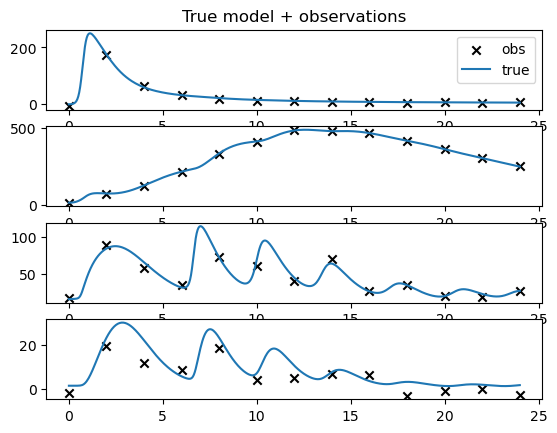

In [22]:
#Generate data
#output_ids = [6, 7] # Neuroendocrine = ACTH + Cort
#output_ids = [3, 6, 7] # TNF + ACTH + Cort
output_ids = [3,4,6,7] #TNF + IL10 + ACTH + Cort

# Define data
nt = len(t_data)
y_data = np.zeros((len(t_data),len(output_ids)))
# Here, we can add Gaussian, iid noise to the observations [REMOVE NOISE?]
for i, time in enumerate(t_data):
    index = np.where(tspace==time)
    for j,out_id in enumerate(output_ids):
        # This was causing an issue - it gave back a vector of 1s
        y_data[i,j] = true_sol[index,out_id]


# If you want to add noise, add it here
y_data = y_data+ np.random.normal(0,4,(nt,len(output_ids)))

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k',label='obs')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true')
plt.title('True model + observations')
plt.legend()
#
plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[1]])

plt.subplot(4,1,3)
plt.scatter(t_data,y_data[:,2],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[2]])

plt.subplot(4,1,4)
plt.scatter(t_data,y_data[:,3],marker='x',color='k')
plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()


In [23]:
paramtitles.index('h10')

23

In [24]:
# Define which parameters will be updated

##MOST SENSITIVE FOR ACTH + CORT
#param_ids = [33,12,36,32,7,34,31,15,8,9]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A
#param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1]
##MOST SENSITIVE FOR ACTH + CORT + TNF-A + 1L10
param_ids = [33,12,36,32,7,34,31,15,8,9,16,14,28,26,1,21,22]

# To make the problem interesting, let's perturb our initial guess of these parameters by 1% [SHOULD WE DO THIS?]
param_in = np.log(np.exp(param_log[param_ids])*np.random.normal(1,0.1,(1,len(param_ids))).flatten())
# print(np.exp(param_log[param_ids]),np.exp(param_in))

# We may also want to constrain the parameters so they do not take on values in "unphysiological" regions
# Define upper bound UB and lower bound LB; remember we are on a log scale!

# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)
print(UB,param_in,LB)


param_all = param_log


# Now, we set up a minimization problem
least_sq_sol = least_squares(OLS_res,param_in,args=(y_data,t_data,param_ids,output_ids,param_all,IC),
                             bounds=(LB,UB),verbose=2,xtol=1e-14,diff_step=1e-4)

print("initial guess",np.exp(param_in))
print("optimal solution",np.exp(least_sq_sol.x))
print("true solution",np.exp(param_log[param_ids]))
print("objective function value",least_sq_sol.cost) ##This thing




[ -1.83258146   0.46310489  -1.32425897   6.68461173 -17.98500979
  -5.45987206   7.02108396   9.64827267   1.60943791   8.51719319
  -1.22758267  12.78026736  -1.13943428  23.58877552  20.02923827
   1.33500107   6.89701784] [ -4.10085014  -1.80856375  -3.70005294   4.16786544 -20.40167805
  -7.70412752   4.74229566   7.50601653  -0.45805449   6.36603442
  -3.68365651  10.60874574  -3.21235777  21.29022827  17.65463235
  -0.8936833    4.60728007] [-11.04292184  -8.74723548 -10.53459934  -2.52572864 -27.19535017
 -14.67021243  -2.18925641   0.4379323   -7.60090246  -0.69314718
 -10.43792304   3.56992698 -10.34977466  14.37843515  10.8188979
  -7.87533931  -2.31332253]


C:\Users\ayres\AppData\Local\Temp\ipykernel_29020\4177219873.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model_output[i,j] = ODE_sol[t_index,mod_out]


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.6638e+01                                    2.43e+03    
       1              2         1.2874e+01      1.38e+01       1.61e+00       4.58e+02    
       2              3         6.5101e+00      6.36e+00       1.42e+00       3.78e+02    
       3              4         4.5609e+00      1.95e+00       5.43e-01       2.00e+03    
       4              5         3.2499e+00      1.31e+00       4.58e-01       3.76e+02    
       5             10         2.9962e+00      2.54e-01       1.52e-03       2.12e+02    
       6             12         2.9655e+00      3.07e-02       7.24e-04       2.32e+01    
       7             13         2.9614e+00      4.08e-03       9.26e-04       3.28e+01    
       8             14         2.9573e+00      4.18e-03       9.49e-04       8.58e+01    
       9             16         2.9546e+00      2.62e-03       1.70e-04       3.61e+01    

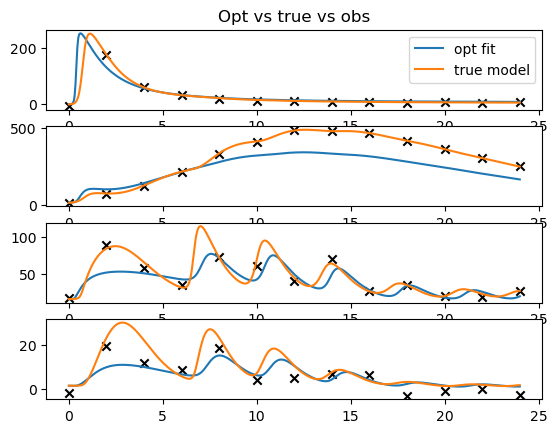

In [25]:
# MJC - plotting to look at solution
param_opt = param_log
param_opt[param_ids] = least_sq_sol.x
opt_model = odeint(ITIS, IC_2, tfinal, args = (param_opt,), **ode_options)

plt.figure()
plt.subplot(4,1,1)
plt.scatter(t_data,y_data[:,0],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[0]],label='opt fit')
plt.plot(tfinal,true_sol[:,output_ids[0]],label='true model')
plt.title('Opt vs true vs obs')
plt.legend()


plt.subplot(4,1,2)
plt.scatter(t_data,y_data[:,1],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[1]])
plt.plot(tfinal,true_sol[:,output_ids[1]])

plt.subplot(4,1,3)
plt.scatter(t_data,y_data[:,2],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[2]])
plt.plot(tfinal,true_sol[:,output_ids[2]])

plt.subplot(4,1,4)
plt.scatter(t_data,y_data[:,3],marker='x',color='k')
plt.plot(tfinal,opt_model[:,output_ids[3]])
plt.plot(tfinal,true_sol[:,output_ids[3]])

plt.show()

In [26]:
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

Sensitivity_Mat = np.zeros((n_param, len(t_data) * n_states))  ##Initialize shape of sensitivity matrix.
for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h ##    [HOW EXACTLY SHOULD I BE PERTURBING MY PARAM?]
        ##THIS THING NEXT DO THIS!!!
        Sensitivity_Mat[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_all, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_all, IC)))

twonorms = np.zeros(n_param)

for i in range(n_param):
        twonorms[i] = np.power(sum(np.power(Sensitivity_Mat[i, :], 2)), 1 / 2)


C:\Users\ayres\AppData\Local\Temp\ipykernel_29020\4177219873.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  model_output[i,j] = ODE_sol[t_index,mod_out]


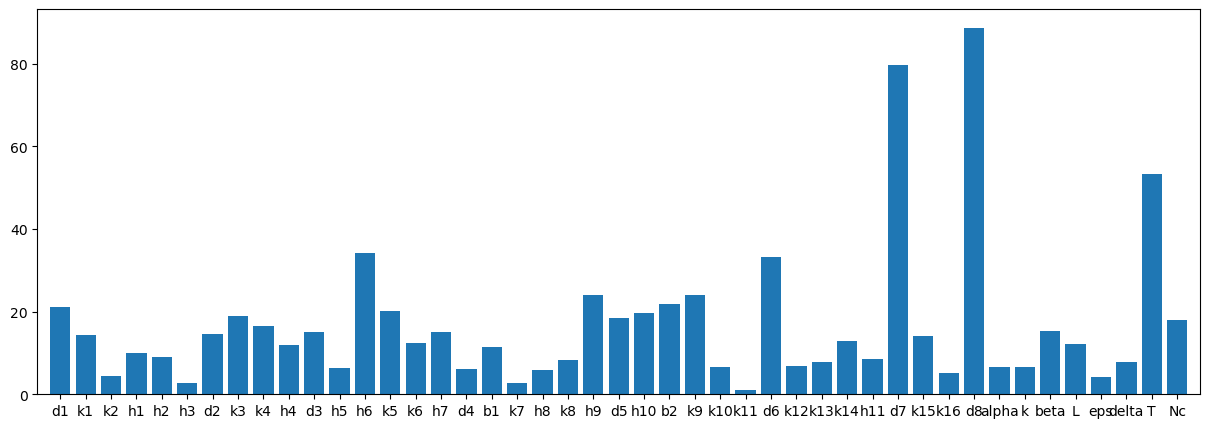

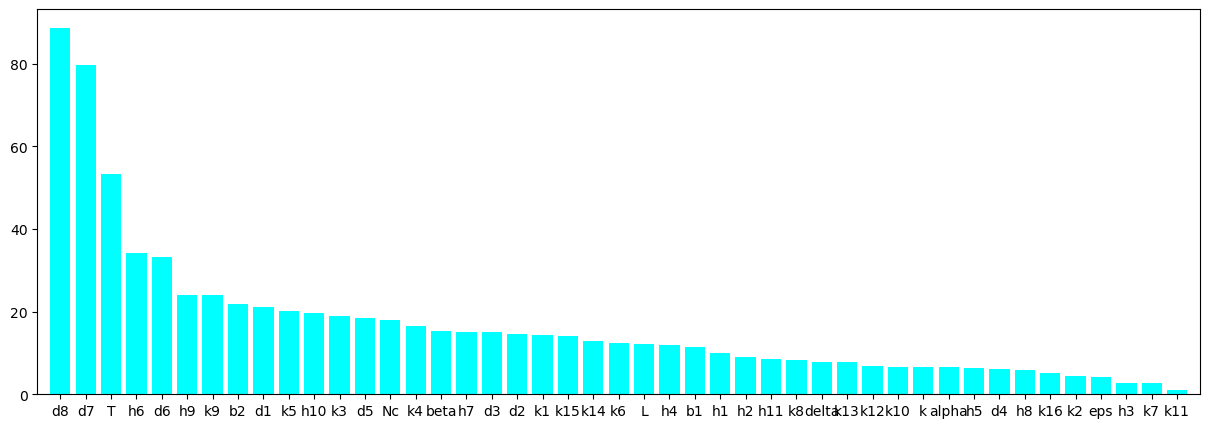

In [27]:
#PLOTTING
paramtitles = ['d1',
               'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
               'k3', 'k4', 'h4', 'd3',
               'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
               'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
               'b2', 'k9', 'k10', 'k11', 'd6',
               'k12', 'k13', 'k14', 'h11', 'd7',
               'k15', 'k16', 'd8',
               'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']

fig, ax = plt.subplots(figsize = (15,5))
ax.bar(paramtitles,twonorms)
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

##Plot in descending order
data = sorted(zip(paramtitles, twonorms), key=lambda v: v[1], reverse = True)

plt.figure(figsize=(15, 5))
for (i, c) in data:  # unpack and plot each tuple in sorted order
    bars = plt.bar(i, c, align='center', color = 'cyan')
plt.xlim(-0.9, len(paramtitles) - 1 + 0.9)

plt.show()

In [28]:
##CURRENT CONCERNS
import pickle

all_results = {
    'output_ids': output_ids,
    'param_ids' : param_ids,
    'param_in' : param_in,
    'twonorms' : twonorms,
    't_data' : t_data,
    'y_data' : y_data,
    'opt_model' : opt_model,
    'true_sol' : true_sol,
    'param_opt' : param_opt,
    'optimal_solution' :np.exp(least_sq_sol.x),
    'objvalue' : least_sq_sol.cost
}

with open('ResAnalysis32.pkl', 'wb') as f:
    pickle.dump(all_results, f)
